In [ ]:
!pip install tensorflow -q

import subprocess
result = subprocess.run(['pip', 'show', 'tensorflow'],
                       capture_output=True, text=True)
print(result.stdout)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 782.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.4 MB/s eta 0:00:00
Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 



In [ ]:
import os
import json

# ── Monter Google Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Dossiers du projet LSTM
PROJECT_DIR = '/content/drive/MyDrive/FinalRNN(BiLSTM)'
DATASET_DIR = f'{PROJECT_DIR}/datasets'
MODEL_DIR   = f'{PROJECT_DIR}/models'
RESULTS_DIR = f'{PROJECT_DIR}/results'

for d in [PROJECT_DIR, DATASET_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive est bien monté")
print(f" Projet    : {PROJECT_DIR}")
print(f" Datasets  : {DATASET_DIR}")
print(f" Modèles   : {MODEL_DIR}")
print(f" Résultats : {RESULTS_DIR}")


# ── Configurer Kaggle ─────────────────────────────────────────
KAGGLE_USERNAME = "r1ppxrr"
KAGGLE_KEY      = "c9bae231d5eeaf2371400614d7b95196"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle -q

print("\n Kaggle est bien configuré")

Mounted at /content/drive
Drive est bien monté
 Projet    : /content/drive/MyDrive/FinalRNN(BiLSTM)
 Datasets  : /content/drive/MyDrive/FinalRNN(BiLSTM)/datasets
 Modèles   : /content/drive/MyDrive/FinalRNN(BiLSTM)/models
 Résultats : /content/drive/MyDrive/FinalRNN(BiLSTM)/results

 Kaggle est bien configuré


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import gc
import psutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder, MinMaxScaler
from sklearn.metrics            import (classification_report,
                                         confusion_matrix,
                                         accuracy_score,
                                         f1_score,
                                         roc_auc_score,
                                         roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow                 import keras
from tensorflow.keras           import layers, regularizers, callbacks
from tensorflow.keras.utils     import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def check_ram():
    ram  = psutil.virtual_memory()
    free = ram.available / 1e9
    used = ram.used / 1e9
    tot  = ram.total / 1e9
    print(f"RAM : {used:.1f}GB utilisés "
          f"| {free:.1f}GB libres | {tot:.1f}GB total")
    if free < 1.5:
        gc.collect()
check_ram()

RAM : 2.1GB utilisés | 47.8GB libres | 50.5GB total


In [ ]:
import os
import glob

csv_in_drive = glob.glob(f'{DATASET_DIR}/*.csv')

if csv_in_drive:
    print(f"Dataset est déjà dans Drive ({len(csv_in_drive)} fichiers)")
    for f in csv_in_drive:
        size = os.path.getsize(f) / 1e6
        print(f"{os.path.basename(f)} → {size:.1f} MB")

else:

    os.makedirs('/content/cicids_raw', exist_ok=True)

    !kaggle datasets download \
        -d chethuhn/network-intrusion-dataset \
        -p /content/cicids_raw -q

    print("Téléchargement du DATASET est terminé")
    print("Décompression")

    import zipfile
    zip_path = '/content/cicids_raw/network-intrusion-dataset.zip'

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_csv = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"\n   Fichiers disponibles ({len(all_csv)}) :")
        for f in all_csv:
            size = z.getinfo(f).file_size / 1e6
            print(f"   📄 {f} → {size:.1f} MB")

        target = next(
            (f for f in all_csv if 'Wednesday' in f
             or 'wednesday' in f),
            all_csv[0]
        )
        print(f"\n Extraction : {target}")
        z.extract(target, '/content/cicids_raw/')

    extracted = glob.glob('/content/cicids_raw/*.csv')
    for f in extracted:
        dest = f'{DATASET_DIR}/{os.path.basename(f)}'
        !cp "{f}" "{dest}"
        print(f"Sauvegardé : {os.path.basename(f)}")

    !rm -rf /content/cicids_raw
    gc.collect()
    print("Dataset prêt dans Drive")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
Téléchargement du DATASET est terminé
Décompression

   Fichiers disponibles (8) :
   📄 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 77.1 MB
   📄 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 76.9 MB
   📄 Friday-WorkingHours-Morning.pcap_ISCX.csv → 58.3 MB
   📄 Monday-WorkingHours.pcap_ISCX.csv → 176.9 MB
   📄 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 83.1 MB
   📄 Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 52.0 MB
   📄 Tuesday-WorkingHours.pcap_ISCX.csv → 135.1 MB
   📄 Wednesday-workingHours.pcap_ISCX.csv → 225.2 MB

 Extraction : Wednesday-workingHours.pcap_ISCX.csv
Sauvegardé : Wednesday-workingHours.pcap_ISCX.csv
Dataset prêt dans Drive


In [ ]:
import pandas as pd
import numpy as np
import gc
import glob
import os

def map_label(lbl):
    lbl = str(lbl).upper().strip()
    if 'BENIGN'   in lbl:                   return 'BENIGN'
    if 'DOS'      in lbl or 'DDOS' in lbl:  return 'DoS'
    if 'PORTSCAN' in lbl or 'SCAN' in lbl:  return 'Probe'
    if 'BRUTE'    in lbl or 'FTP'  in lbl \
       or 'SSH'   in lbl:                   return 'R2L'
    if 'BOT'      in lbl:                   return 'Bot'
    if 'WEB'      in lbl or 'SQL'  in lbl \
       or 'XSS'   in lbl:                   return 'WebAttack'
    if 'INFILTR'  in lbl:                   return 'U2R'
    if 'HEART'    in lbl:                   return 'DoS'
    return 'Other'

csv_files = glob.glob(f'{DATASET_DIR}/*.csv')
print(f"Fichier : {os.path.basename(csv_files[0])}")

# LSTM : moins de lignes car les séquences prennent plus de RAM
CHUNK_SIZE = 50000
MAX_LIGNES = 150000

print(f"\n Lecture par chunks ({CHUNK_SIZE:,} lignes)...")
print(f"Maximum : {MAX_LIGNES:,} lignes")
print(f"(réduit vs DNN/CNN car LSTM crée des séquences)")

frames = []
total  = 0

for i, chunk in enumerate(pd.read_csv(
        csv_files[0],
        chunksize=CHUNK_SIZE,
        low_memory=False)):

    chunk.columns = chunk.columns.str.strip()
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    lbl_col = next(
        (c for c in chunk.columns if 'label' in c.lower()),
        None
    )
    if lbl_col is None:
        continue

    chunk[lbl_col] = chunk[lbl_col].apply(map_label)
    chunk.rename(columns={lbl_col: 'label'}, inplace=True)

    frames.append(chunk)
    total += len(chunk)
    print(f"   Chunk {i+1} : {total:,} lignes")

    if total >= MAX_LIGNES:
        print(f"Limite atteinte → arrêt")
        break

df = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

print(f"\n Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n Distribution :")
print(df['label'].value_counts())

check_ram()

Fichier : Wednesday-workingHours.pcap_ISCX.csv

 Lecture par chunks (50,000 lignes)...
Maximum : 150,000 lignes
(réduit vs DNN/CNN car LSTM crée des séquences)
   Chunk 1 : 50,000 lignes
   Chunk 2 : 100,000 lignes
   Chunk 3 : 150,000 lignes
Limite atteinte → arrêt

 Dataset : 150,000 lignes × 79 colonnes

 Distribution :
label
DoS       82787
BENIGN    67213
Name: count, dtype: int64
RAM : 2.3GB utilisés | 47.6GB libres | 50.5GB total


In [ ]:
import numpy as np
import gc
import psutil
import tensorflow as tf
from sklearn.preprocessing   import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils  import to_categorical

gc.collect()
tf.keras.backend.clear_session()

print("  PRÉTRAITEMENT LSTM")
check_ram()

# Paramètres LSTM
TIMESTEPS  = 10   # longueur de la fenêtre glissante
N_TOP      = 20   # features (réduit vs DNN/CNN pour économiser RAM)

# ── A. Séparer features et labels ───────────────────────────────
print("\n[A] Séparation features / labels...")

drop_cols = ['label']
feat_cols = [
    c for c in df.columns
    if c not in drop_cols
    and df[c].dtype in [np.float64, np.float32,
                         np.int64, np.int32]
]

X_raw = df[feat_cols].values.astype(np.float32)
y_raw = df['label'].values.copy()

del df
gc.collect()

print(f"Features : {X_raw.shape[1]}")
print(f"Lignes   : {X_raw.shape[0]:,}")
check_ram()

# ── B. Nettoyage ─────────────────────────────────────────────────
print("\n[B] Nettoyage...")

X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = X_raw.astype(np.float32)

col_medians = np.nanmedian(X_raw, axis=0)
nan_mask    = np.isnan(X_raw)
for j in range(X_raw.shape[1]):
    X_raw[nan_mask[:, j], j] = col_medians[j]

std_vals       = np.std(X_raw, axis=0)
good_cols      = std_vals > 0
X_raw          = X_raw[:, good_cols]
feat_cols_kept = [feat_cols[i]
                  for i in range(len(feat_cols)) if good_cols[i]]

gc.collect()
print(f"Features après nettoyage : {X_raw.shape[1]}")

# ── C. Encoder les labels ────────────────────────────────────────
print("\n[C] Encodage des labels...")

le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
N_CLASSES   = len(le.classes_)
CLASS_NAMES = list(le.classes_)

del y_raw
gc.collect()

print(f"Nombre de classes : {N_CLASSES}")
for i, cls in enumerate(CLASS_NAMES):
    count = int((y_enc == i).sum())
    pct   = count / len(y_enc) * 100
    print(f"      {cls:<12} : {count:,} ({pct:.1f}%)")

# ── D. Sélection features par variance ──────────────────────────
print(f"\n[D] Sélection des {N_TOP} meilleures features...")

variances   = np.var(X_raw, axis=0)
top_indices = np.argsort(variances)[::-1][:N_TOP]
X_selected  = X_raw[:, top_indices].astype(np.float32)
FEAT_NAMES  = [feat_cols_kept[i] for i in top_indices]
K           = X_selected.shape[1]

del X_raw
gc.collect()

print(f" Features sélectionnées : {K}")
print(f"Les Top 5 sont : {FEAT_NAMES[:5]}")
check_ram()

# ── E. Normalisation AVANT création des séquences ───────────────
print("\n[E] Normalisation MinMaxScaler...")

# IMPORTANT : normaliser AVANT le sliding window
# pour que toutes les séquences aient des valeurs cohérentes
scaler     = MinMaxScaler()
X_scaled   = scaler.fit_transform(X_selected).astype(np.float32)

del X_selected
gc.collect()

print("Normalisation est terminée")
check_ram()

# ── F. Création des séquences (Sliding Window) ──────────────────
print(f"\n[F] Création des séquences LSTM...")
print(f"   Méthode    : Sliding Window")
print(f"   Timesteps  : {TIMESTEPS}")
print(f"   Lignes     : {X_scaled.shape[0]:,}")
print(f"   → Séquences attendues : {X_scaled.shape[0] - TIMESTEPS:,}")

def create_sequences(X, y, timesteps):
    """
    Transforme les données 2D en séquences 3D pour le LSTM.

    Input  : X shape (N, K), y shape (N,)
    Output : Xs shape (N-timesteps, timesteps, K)
             ys shape (N-timesteps,)

    Le label de chaque séquence = label du DERNIER
    échantillon de la fenêtre.
    """
    n_seq = len(X) - timesteps
    # Pré-allouer le tableau pour éviter les copies en mémoire
    Xs = np.empty((n_seq, timesteps, X.shape[1]), dtype=np.float32)
    ys = np.empty(n_seq, dtype=np.int64)
    for i in range(n_seq):
        Xs[i] = X[i : i + timesteps]
        ys[i] = y[i + timesteps]
    return Xs, ys

X_seq, y_seq = create_sequences(X_scaled, y_enc, TIMESTEPS)

del X_scaled, y_enc
gc.collect()

print(f"\n Séquences créées !")
print(f"Forme LSTM : {X_seq.shape}")
print(f"(N={X_seq.shape[0]:,}, timesteps={TIMESTEPS}, features={K})")
check_ram()

# ── G. Split train / val / test ──────────────────────────────────
print("\n[G] Split des données...")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq, y_seq,
    test_size=0.15,
    random_state=SEED,
    stratify=y_seq
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.12,
    random_state=SEED,
    stratify=y_tr
)

del X_seq, y_seq
gc.collect()

print(f"Train      : {X_tr.shape[0]:,} séquences")
print(f"Validation : {X_val.shape[0]:,} séquences")
print(f"Test       : {X_te.shape[0]:,} séquences")

# ── H. One-Hot Encoding ──────────────────────────────────────────
print("\n[H] One-Hot Encoding...")

y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
y_val_cat = to_categorical(y_val, N_CLASSES)
y_te_cat  = to_categorical(y_te,  N_CLASSES)

# ── Résumé ───────────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"  X_train LSTM : {X_tr.shape}")
print(f"  X_val   LSTM : {X_val.shape}")
print(f"  X_test  LSTM : {X_te.shape}")
print(f"  Classes      : {CLASS_NAMES}")
print(f"{'─'*45}")
check_ram()

  PRÉTRAITEMENT LSTM
RAM : 2.3GB utilisés | 47.6GB libres | 50.5GB total

[A] Séparation features / labels...
Features : 78
Lignes   : 150,000
RAM : 2.3GB utilisés | 47.6GB libres | 50.5GB total

[B] Nettoyage...
Features après nettoyage : 68

[C] Encodage des labels...
Nombre de classes : 2
      BENIGN       : 67,213 (44.8%)
      DoS          : 82,787 (55.2%)

[D] Sélection des 20 meilleures features...
 Features sélectionnées : 20
Les Top 5 sont : ['Fwd IAT Total', 'Flow Duration', 'Flow Bytes/s', 'Idle Max', 'Fwd IAT Max']
RAM : 2.3GB utilisés | 47.6GB libres | 50.5GB total

[E] Normalisation MinMaxScaler...
Normalisation est terminée
RAM : 2.3GB utilisés | 47.6GB libres | 50.5GB total

[F] Création des séquences LSTM...
   Méthode    : Sliding Window
   Timesteps  : 10
   Lignes     : 150,000
   → Séquences attendues : 149,990

 Séquences créées !
Forme LSTM : (149990, 10, 20)
(N=149,990, timesteps=10, features=20)
RAM : 2.4GB utilisés | 47.5GB libres | 50.5GB total

[G] Split de

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import gc

gc.collect()

def build_lstm(timesteps, n_features, n_classes):
    """
    Construit le BiLSTM pour la détection d'intrusions.
    timesteps  : longueur de la séquence (TIMESTEPS=10)
    n_features : nombre de features (K=20)
    n_classes  : nombre de classes (7)
    """

    inputs = keras.Input(
        shape=(timesteps, n_features),
        name='input_sequence'
    )

    # ══ BiLSTM 1 : return_sequences=True ════════════════════════
    # return_sequences=True car on empile un 2ème LSTM après
    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.20,
            recurrent_dropout=0.10,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        name='bilstm_1'
    )(inputs)
    x = layers.Dropout(0.30, name='drop_lstm1')(x)

    # ══ BiLSTM 2 : return_sequences=False ═══════════════════════
    # return_sequences=False → retourne seulement le résumé final
    x = layers.Bidirectional(
        layers.LSTM(
            32,
            return_sequences=False,
            dropout=0.20,
            recurrent_dropout=0.10,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        name='bilstm_2'
    )(x)
    x = layers.Dropout(0.25, name='drop_lstm2')(x)

    # ══ COUCHES DENSES ══════════════════════════════════════════
    x = layers.Dense(
            64,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='fc1'
        )(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.30, name='drop_fc1')(x)

    x = layers.Dense(
            32,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='fc2'
        )(x)
    x = layers.BatchNormalization(name='bn_fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)
    x = layers.Dropout(0.20, name='drop_fc2')(x)

    # ══ SORTIE ══════════════════════════════════════════════════
    outputs = layers.Dense(
        n_classes,
        activation='softmax',
        name='output'
    )(x)

    model = keras.Model(inputs, outputs, name='IDS_BiLSTM')
    return model

# Construire le modèle
N_FEATURES_LSTM = X_tr.shape[2]   # = K = 20
model_lstm      = build_lstm(TIMESTEPS, N_FEATURES_LSTM, N_CLASSES)
model_lstm.summary()

print(f"\n Modèle BiLSTM construit")
print(f"   Paramètres  : {model_lstm.count_params():,}")
print(f"   Input shape : ({TIMESTEPS}, {N_FEATURES_LSTM})")
print(f"   Output      : ({N_CLASSES},) → {CLASS_NAMES}")

Model: "IDS_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 10, 128)        │        43,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm1 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc1 (Activation)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc2 (BatchNormalization)     │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc2 (Activation)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,426 (357.13 KB)

 Trainable params: 91,234 (356.38 KB)

 Non-trainable params: 192 (768.00 B)


 Modèle BiLSTM construit
   Paramètres  : 91,426
   Input shape : (10, 20)
   Output      : (2,) → ['BENIGN', 'DoS']


In [ ]:
import gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks
from sklearn.utils.class_weight import compute_class_weight

gc.collect()
tf.keras.backend.clear_session()

# Reconstruire après clear_session
model_lstm = build_lstm(TIMESTEPS, N_FEATURES_LSTM, N_CLASSES)
print("Modèle BiLSTM reconstruit")

# ── Class weights ────────────────────────────────────────────────
cw = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
class_weight_dict = dict(enumerate(cw))
print("\n Class weights :")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, cw)):
    print(f"   {cls:<12} : {w:.3f}")

# ── Paramètres ───────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 64     # ← plus petit (séquences LSTM très lourdes)
LR         = 5e-4   # ← plus petit que DNN/CNN (LSTM sensible au LR)

print(f"\n  Époques    : {EPOCHS}")
print(f" Batch size : {BATCH_SIZE}")
print(f" LR initial : {LR}")
print(f" Input LSTM : {X_tr.shape}")

# ── Compilation avec Gradient Clipping ───────────────────────────
# clipnorm=1.0 → évite l'explosion des gradients dans le LSTM
# LR = float → compatible avec ReduceLROnPlateau
model_lstm.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LR,
        clipnorm=1.0        # ← IMPORTANT pour le LSTM !
    ),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("\n Modèle compilé avec Gradient Clipping")

# ── Callbacks ────────────────────────────────────────────────────
BEST_MODEL = f'{MODEL_DIR}/best_lstm.keras'

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: gc.collect()
    )
]

# ── tf.data.Dataset ──────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_tr, y_tr_cat)
).shuffle(
    buffer_size=3000,   # ← plus petit buffer pour LSTM
    seed=SEED
).batch(BATCH_SIZE
).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val_cat)
).batch(BATCH_SIZE
).prefetch(AUTOTUNE)

print("tf.data.Dataset prêt")
check_ram()

# ── Entraînement ─────────────────────────────────────────────────

history = model_lstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

del train_ds, val_ds
gc.collect()

print(f"\n Entraînement terminé !")
print(f" Modèle : {BEST_MODEL}")
check_ram()

Modèle BiLSTM reconstruit

 Class weights :
   BENIGN       : 1.116
   DoS          : 0.906

  Époques    : 50
 Batch size : 64
 LR initial : 0.0005
 Input LSTM : (112192, 10, 20)

 Modèle compilé avec Gradient Clipping
tf.data.Dataset prêt
RAM : 2.5GB utilisés | 47.4GB libres | 50.5GB total
Epoch 1/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.8091 - auc: 0.8976 - loss: 0.5168 - precision: 0.8091 - recall: 0.8091 - val_accuracy: 0.8844 - val_auc: 0.9451 - val_loss: 0.4322 - val_precision: 0.8844 - val_recall: 0.8844 - learning_rate: 5.0000e-04
Epoch 2/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.8746 - auc: 0.9354 - loss: 0.4421 - precision: 0.8746 - recall: 0.8746 - val_accuracy: 0.8938 - val_auc: 0.9477 - val_loss: 0.4164 - val_precision: 0.8938 - val_recall: 0.8938 - learning_rate: 5.0000e-04
Epoch 3/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.8837 - auc: 0.9418 - loss: 0.4224 - precision: 0.8837 - recall: 0.8837 - val_accuracy: 0.

In [ ]:
import numpy as np
import gc
import tensorflow as tf
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
from tensorflow.keras.utils import to_categorical

gc.collect()

print("  Évaluation sur le jeu de test")

# Prédictions sur X_te (séquences 3D)
y_pred_proba = model_lstm.predict(
    X_te, batch_size=128, verbose=0
)
y_pred = np.argmax(y_pred_proba, axis=1)

# Métriques
acc  = accuracy_score(y_te, y_pred)
f1_w = f1_score(y_te, y_pred, average='weighted', zero_division=0)
f1_m = f1_score(y_te, y_pred, average='macro',    zero_division=0)

# AUC-ROC
try:
    y_te_bin = to_categorical(y_te, N_CLASSES)
    auc_list = []
    for i in range(N_CLASSES):
        if len(np.unique(y_te_bin[:, i])) > 1:
            auc_list.append(
                roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
            )
    auc_mean = float(np.mean(auc_list))
except Exception:
    auc_mean = 0.0

# Affichage
print(f"\n MÉTRIQUES GLOBALES")
print(f"  {'─'*40}")
print(f"  Accuracy          : {acc*100:.2f} %")
print(f"  F1-Score Weighted : {f1_w*100:.2f} %")
print(f"  F1-Score Macro    : {f1_m*100:.2f} %")
print(f"  AUC-ROC moyen     : {auc_mean:.4f}")
print(f"  {'─'*40}")

print(f"\n RAPPORT PAR CLASSE :")
print(classification_report(
    y_te, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

CM = confusion_matrix(y_te, y_pred)

  Évaluation sur le jeu de test

 MÉTRIQUES GLOBALES
  ────────────────────────────────────────
  Accuracy          : 96.41 %
  F1-Score Weighted : 96.41 %
  F1-Score Macro    : 96.37 %
  AUC-ROC moyen     : 0.9795
  ────────────────────────────────────────

 RAPPORT PAR CLASSE :
              precision    recall  f1-score   support

      BENIGN     0.9630    0.9566    0.9598     10081
         DoS     0.9649    0.9702    0.9676     12418

    accuracy                         0.9641     22499
   macro avg     0.9640    0.9634    0.9637     22499
weighted avg     0.9641    0.9641    0.9641     22499



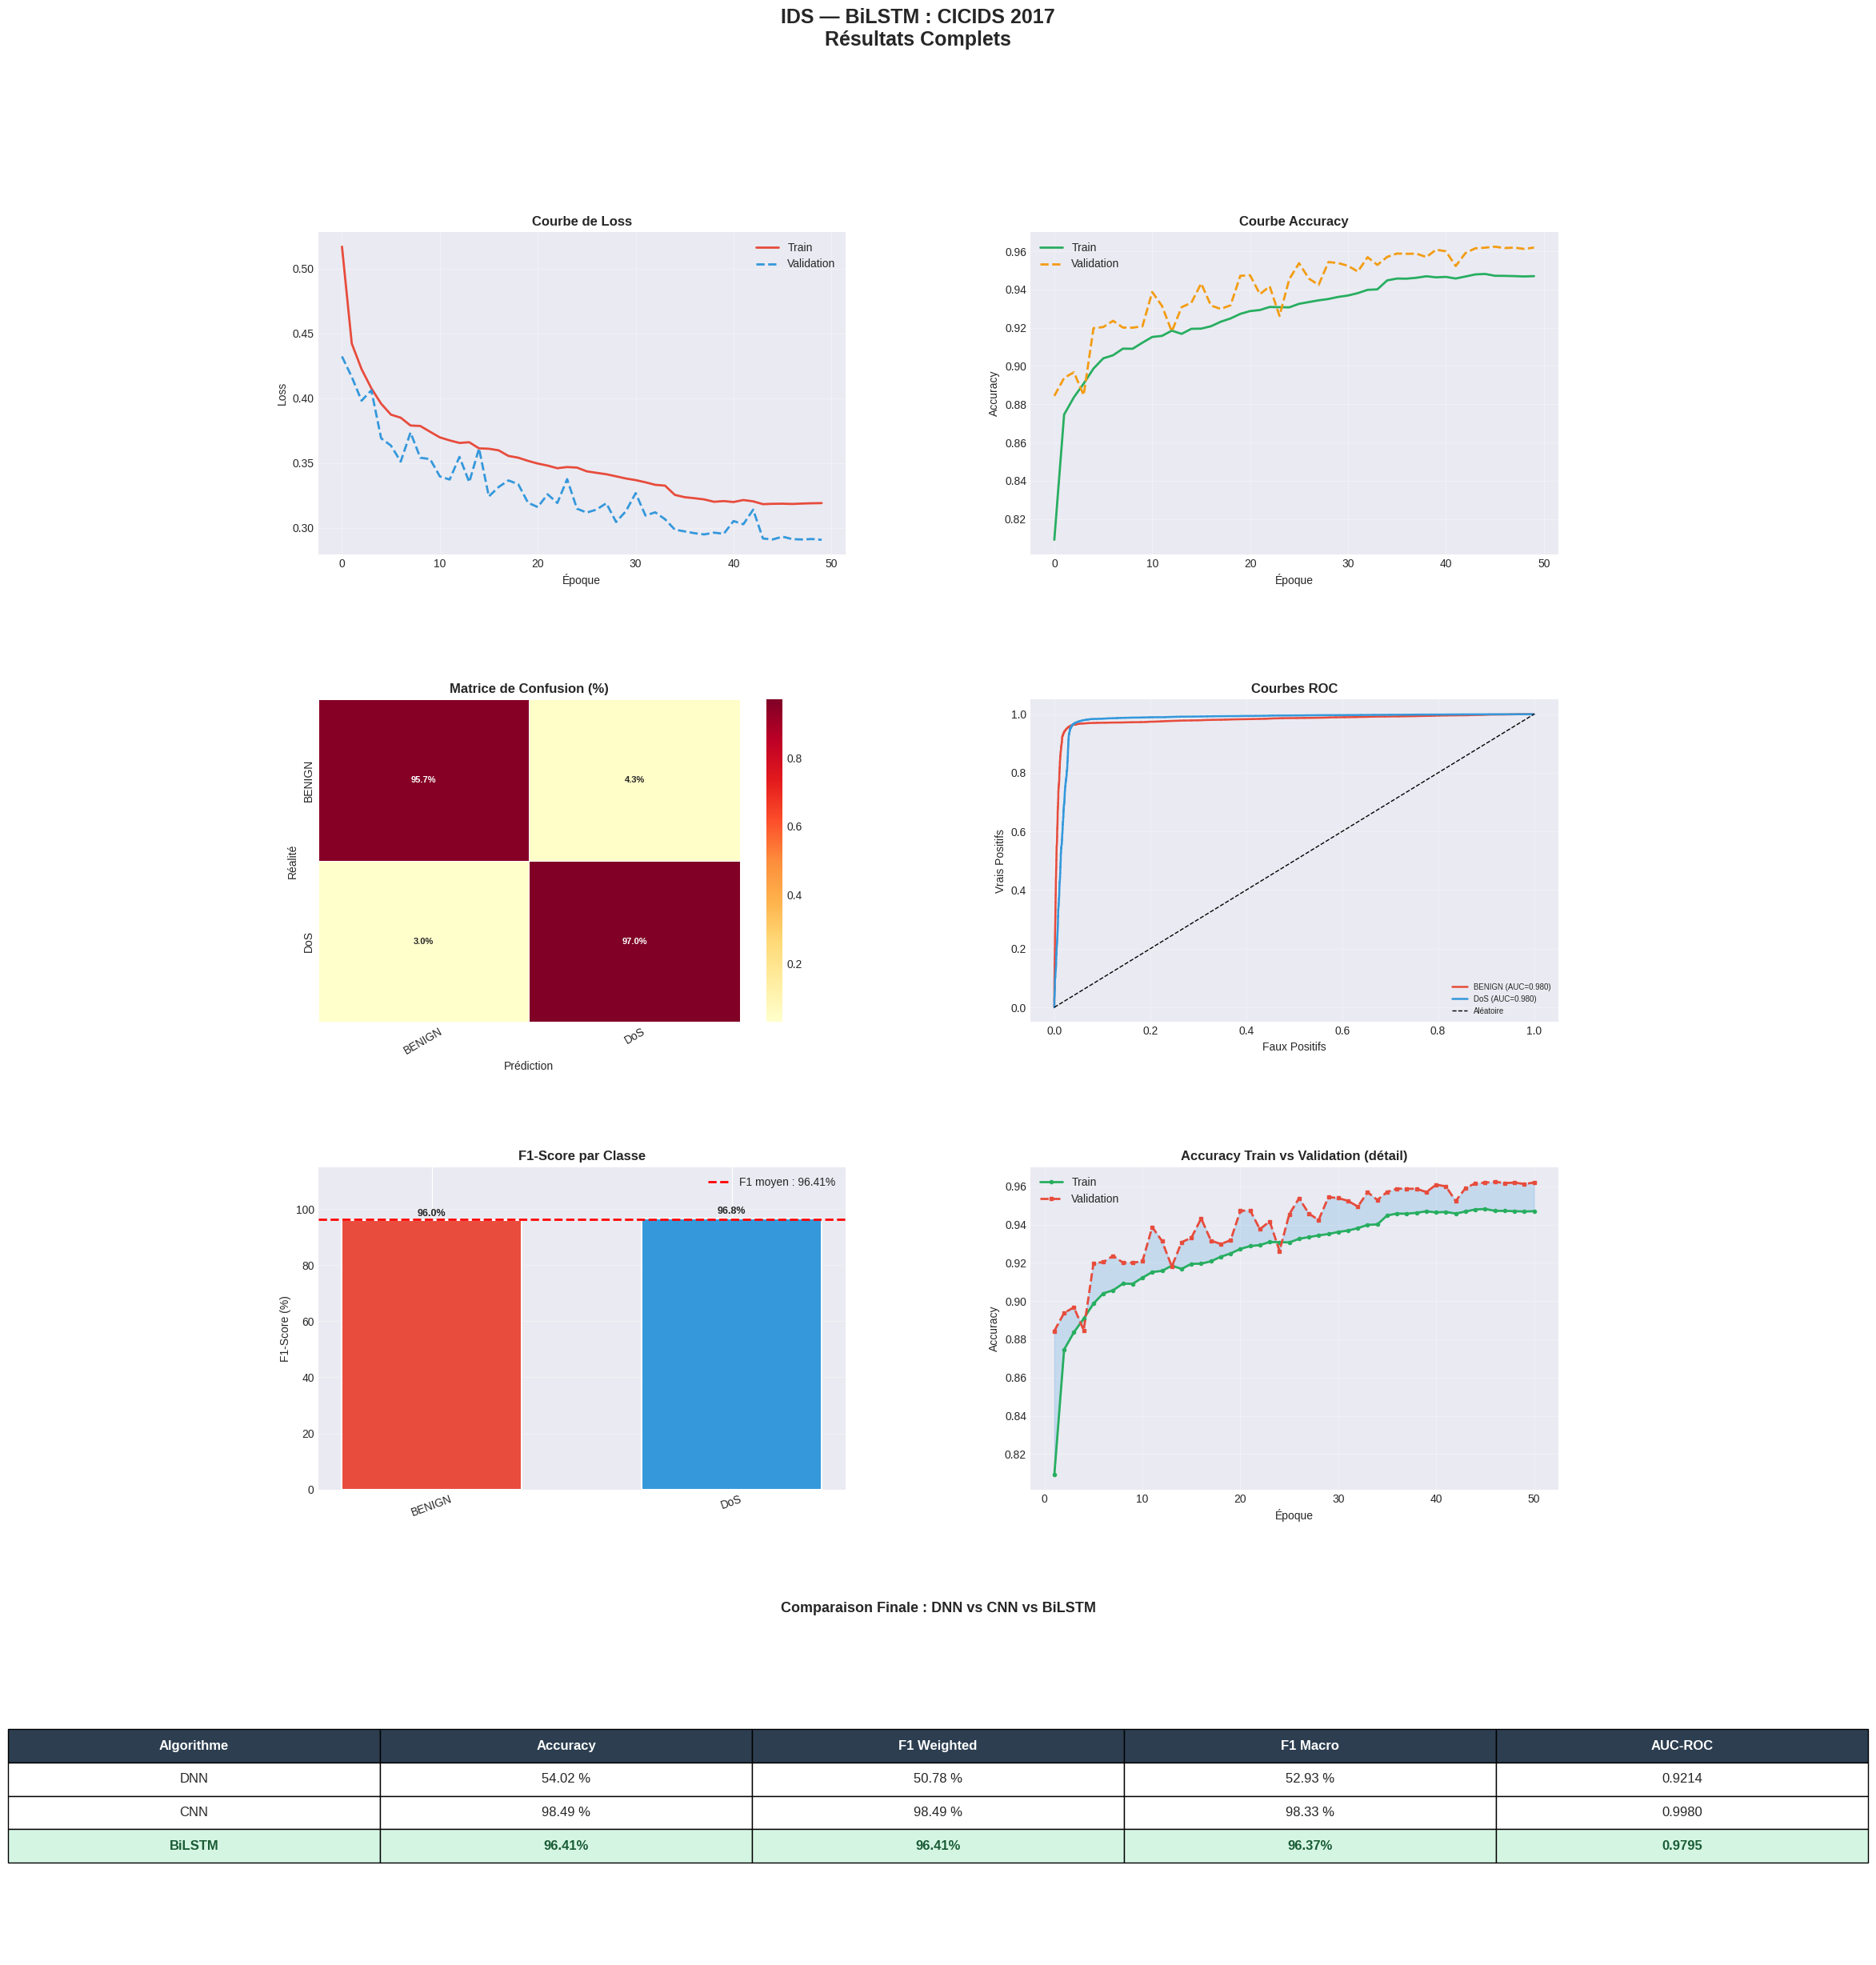

Graphes sont bien sauvegardés : /content/drive/MyDrive/FinalRNN(BiLSTM)/results/LSTM_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import gc
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from tensorflow.keras.utils import to_categorical

plt.style.use('seaborn-v0_8-darkgrid')

PALETTE = ['#e74c3c','#3498db','#27ae60','#f39c12',
           '#8e44ad','#1abc9c','#e67e22']

fig = plt.figure(figsize=(20, 28))
fig.suptitle(
    'IDS — BiLSTM : CICIDS 2017\nRésultats Complets',
    fontsize=18, fontweight='bold'
)
gs = gridspec.GridSpec(4, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── 1. Loss ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'],
         color='#e74c3c', lw=2, label='Train')
ax1.plot(history.history['val_loss'],
         color='#3498db', lw=2, ls='--', label='Validation')
ax1.set_title('Courbe de Loss', fontweight='bold', fontsize=12)
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 2. Accuracy ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['accuracy'],
         color='#27ae60', lw=2, label='Train')
ax2.plot(history.history['val_accuracy'],
         color='#f39c12', lw=2, ls='--', label='Validation')
ax2.set_title('Courbe Accuracy', fontweight='bold', fontsize=12)
ax2.set_xlabel('Époque')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── 3. Matrice de Confusion ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
cm_norm = CM.astype(float) / CM.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%',
    cmap='YlOrRd', ax=ax3,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    annot_kws={"size": 8, "weight": "bold"}
)
ax3.set_title('Matrice de Confusion (%)',
               fontweight='bold', fontsize=12)
ax3.set_xlabel('Prédiction')
ax3.set_ylabel('Réalité')
ax3.tick_params(axis='x', rotation=30)

# ── 4. Courbes ROC ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
y_te_bin = to_categorical(y_te, N_CLASSES)
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_pred_proba[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
    ax4.plot(fpr, tpr, color=color, lw=1.8,
             label=f'{cls_name} (AUC={auc_i:.3f})')
ax4.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax4.set_title('Courbes ROC', fontweight='bold', fontsize=12)
ax4.set_xlabel('Faux Positifs')
ax4.set_ylabel('Vrais Positifs')
ax4.legend(fontsize=7, loc='lower right')
ax4.grid(True, alpha=0.3)

# ── 5. F1 par classe ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)),
                   zero_division=0)
bars = ax5.bar(
    CLASS_NAMES, f1_cls * 100,
    color=[PALETTE[i % len(PALETTE)] for i in range(N_CLASSES)],
    edgecolor='white', linewidth=1.5, width=0.6
)
for bar, val in zip(bars, f1_cls):
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val*100:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax5.axhline(y=f1_w*100, color='red', ls='--', lw=2,
             label=f'F1 moyen : {f1_w*100:.2f}%')
ax5.set_title('F1-Score par Classe',
               fontweight='bold', fontsize=12)
ax5.set_ylabel('F1-Score (%)')
ax5.set_ylim(0, 115)
ax5.legend()
ax5.grid(True, axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=20)

# ── 6. Courbe Accuracy Train vs Val (zoom) ───────────────────────
ax6 = fig.add_subplot(gs[2, 1])
epochs_range = range(1, len(history.history['accuracy']) + 1)
ax6.fill_between(epochs_range,
                  history.history['accuracy'],
                  history.history['val_accuracy'],
                  alpha=0.2, color='#3498db')
ax6.plot(epochs_range, history.history['accuracy'],
         color='#27ae60', lw=2, label='Train', marker='o',
         markersize=3)
ax6.plot(epochs_range, history.history['val_accuracy'],
         color='#e74c3c', lw=2, ls='--', label='Validation',
         marker='s', markersize=3)
ax6.set_title('Accuracy Train vs Validation (détail)',
               fontweight='bold', fontsize=12)
ax6.set_xlabel('Époque')
ax6.set_ylabel('Accuracy')
ax6.legend()
ax6.grid(True, alpha=0.3)

# ── 7. Tableau comparatif DNN vs CNN vs LSTM ─────────────────────
# Mets à jour avec tes vrais résultats DNN et CNN !
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')

# Remplace les valeurs DNN et CNN par tes vrais résultats
table_data = [
    ['Algorithme', 'Accuracy', 'F1 Weighted', 'F1 Macro', 'AUC-ROC'],
    ['DNN',   '54.02 %',  '50.78 %',  '52.93 %',  '0.9214'],
    ['CNN',   '98.49 %',  '98.49 %',  '98.33 %',  '0.9980'],
    ['BiLSTM',
     f'{acc*100:.2f}%',
     f'{f1_w*100:.2f}%',
     f'{f1_m*100:.2f}%',
     f'{auc_mean:.4f}'],
]

table = ax7.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2.5)

# Style entête
for j in range(5):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style ligne BiLSTM (verte)
for j in range(5):
    table[3, j].set_facecolor('#d5f5e3')
    table[3, j].set_text_props(fontweight='bold', color='#1a5c36')

ax7.set_title(
    'Comparaison Finale : DNN vs CNN vs BiLSTM',
    fontweight='bold', fontsize=13, pad=20
)

# ── Sauvegarde ───────────────────────────────────────────────────
GRAPH = f'{RESULTS_DIR}/LSTM_results.png'
plt.tight_layout()
plt.savefig(GRAPH, dpi=150, bbox_inches='tight')
plt.show()

gc.collect()
print(f"Graphes sont bien sauvegardés : {GRAPH}")

In [ ]:
import gc
from sklearn.metrics import f1_score

gc.collect()

# Sauvegarder le modèle
FINAL = f'{MODEL_DIR}/LSTM_final.keras'
model_lstm.save(FINAL)
print(f"Modèle sauvegardé : {FINAL}")

f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)),
                   zero_division=0)

summary = f"""
{'='*55}
  RÉSUMÉ FINAL — IDS basée BiLSTM — CICIDS 2017
{'='*55}
  Accuracy          : {acc*100:.2f} %
  F1-Score Weighted : {f1_w*100:.2f} %
  F1-Score Macro    : {f1_m*100:.2f} %
  AUC-ROC moyen     : {auc_mean:.4f}
  Paramètres        : {model_lstm.count_params():,}
  Timesteps         : {TIMESTEPS}
  Features/step     : {N_FEATURES_LSTM}
  Classes           : {CLASS_NAMES}
{'─'*55}
  F1 par classe :
"""
for cls, val in zip(CLASS_NAMES, f1_cls):
    bar = '█' * int(val * 20)
    summary += f"  {cls:<12} : {val*100:5.2f}%  {bar}\n"

summary += f"""{'─'*55}
  Architecture BiLSTM :
  Input({TIMESTEPS}, {N_FEATURES_LSTM})
  → BiLSTM(64, return_seq=True)  + Dropout(0.30)
  → BiLSTM(32, return_seq=False) + Dropout(0.25)
  → Dense(64) + BN + ReLU + Dropout(0.30)
  → Dense(32) + BN + ReLU + Dropout(0.20)
  → Softmax({N_CLASSES})
  Optimiseur : Adam LR=5e-4 + clipnorm=1.0
  Loss       : CategoricalCrossentropy (smoothing=0.1)
{'─'*55}
  COMPARAISON FINALE (mets à jour avec tes résultats) :
  DNN    → Accuracy : ??%   F1 : ??%
  CNN    → Accuracy : ??%   F1 : ??%
  BiLSTM → Accuracy : {acc*100:.2f}%   F1 : {f1_w*100:.2f}%
{'='*55}
"""

print(summary)

with open(f'{RESULTS_DIR}/LSTM_summary.txt', 'w') as f:
    f.write(summary)

print(f"Résumé sauvegardé : {RESULTS_DIR}/LSTM_summary.txt")
print(f"\n Fichiers dans Drive :")
print(f"   {MODEL_DIR}/LSTM_final.keras")
print(f"   {RESULTS_DIR}/LSTM_results.png")
print(f"   {RESULTS_DIR}/LSTM_summary.txt")

Modèle sauvegardé : /content/drive/MyDrive/FinalRNN(BiLSTM)/models/LSTM_final.keras

  RÉSUMÉ FINAL — IDS basée BiLSTM — CICIDS 2017
  Accuracy          : 96.41 %
  F1-Score Weighted : 96.41 %
  F1-Score Macro    : 96.37 %
  AUC-ROC moyen     : 0.9795
  Paramètres        : 91,426
  Timesteps         : 10
  Features/step     : 20
  Classes           : ['BENIGN', 'DoS']
───────────────────────────────────────────────────────
  F1 par classe :
  BENIGN       : 95.98%  ███████████████████
  DoS          : 96.76%  ███████████████████
───────────────────────────────────────────────────────
  Architecture BiLSTM :
  Input(10, 20)
  → BiLSTM(64, return_seq=True)  + Dropout(0.30)
  → BiLSTM(32, return_seq=False) + Dropout(0.25)
  → Dense(64) + BN + ReLU + Dropout(0.30)
  → Dense(32) + BN + ReLU + Dropout(0.20)
  → Softmax(2)
  Optimiseur : Adam LR=5e-4 + clipnorm=1.0
  Loss       : CategoricalCrossentropy (smoothing=0.1)
───────────────────────────────────────────────────────
  COMPARAISON FINA